You are working with two complementary datasets describing a large-scale biotechnological production process.

The first dataset (“4000 series operating data”) contains high-frequency sensor measurements collected every 5–15 minutes over several hundred hours for 22 individual batches. It includes 17 process variables such as liquid inflows, gas inflows, pH, off-gas measurements, pressure, and oxygen levels. In total, the dataset contains approximately 1.4 million time-stamped observations. Some values are missing due to sensor limitations or non-operational readings, but all batches are considered representative of normal process operation.

The second dataset contains laboratory measurements recorded approximately every 4 hours for 21 batches. This dataset includes the product concentration values over time, which are used to calculate a yield parameter for each batch. By combining the time-series sensor data with the laboratory product data, it is possible to construct a data-driven model to identify which process variables most strongly influence product yield and to predict the yield of a previously unseen batch.

The operating dataset contains 83,204 time-series observations across 18 columns. Each row corresponds to a timestamped measurement for a specific batch. The Batch column is an integer identifier, Date and time is stored as a datetime variable, and all process variables (LIQUID, GAS, OFFGAS, PRESSURE, pH, and OXYGEN) are continuous numerical features stored as float64. Some missing values are present due to sensor downtime or non-operational readings.

To reduce dimensionality and improve interpretability, related sensor streams were aggregated. The six liquid inflow variables were summed into TOTAL_LIQUID_INFLOW, the four gas inflow variables into TOTAL_GAS_INFLOW, the two off-gas sensors were averaged into TOTAL_OFFGAS, and the two pressure sensors were averaged into MEAN_PRESSURE. This transformation reduces redundancy from multiple sensors measuring similar physical phenomena, mitigates noise between parallel sensors, and simplifies the feature space while preserving the key process information relevant for yield prediction.

Feature Aggregation and Dimensionality Reduction

The operating dataset contains multiple sensor measurements representing similar physical quantities recorded from parallel inflow streams and duplicate sensors. To improve interpretability and reduce redundancy, related variables were aggregated into composite features.

The six liquid inflow variables (LIQUID, LIQUID.1, LIQUID.2, LIQUID.3, LIQUID.4, LIQUID.5) represent separate feed streams entering the same bioreactor. Since the overall system behaviour depends on the total liquid entering the reactor, these variables were summed to create a single feature, TOTAL_LIQUID_INFLOW. Similarly, the four gas inflow variables (GAS, GAS.1, GAS.2, GAS.3) were summed to form TOTAL_GAS_INFLOW, representing the total gas supply to the system.

In contrast, the OFFGAS and PRESSURE variables represent duplicate sensors measuring the same physical process conditions. These were averaged to create TOTAL_OFFGAS and MEAN_PRESSURE, respectively. Averaging improves robustness by reducing measurement noise and mitigating small calibration differences between sensors, while preserving the true underlying process state.

Following aggregation, the original individual sensor columns were removed to reduce dimensionality and multicollinearity. This simplification improves model stability, reduces the risk of overfitting, and ensures that the features more directly reflect the underlying physical processes influencing product yield.

Import data

In [2]:
from applied.data_processing import (
    load_operating_data,
    load_product_data,
    compute_product_rate,
    build_features_and_target,
    aggregate_operating_timeseries
)

In [3]:
from pathlib import Path

# Project root = one level above notebooks/
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

In [4]:
op_df = aggregate_operating_timeseries(op_df)

In [5]:
op_df

pH  OXYGEN  TOTAL_LIQUID_INFLOW  \
Batch Date and time                                            
4030  2019-01-03 00:01:00  5.62   11.60             25682.29   
      2019-01-03 00:16:00  5.63   11.90             25582.07   
      2019-01-03 00:31:00  5.63   11.79             25592.72   
      2019-01-03 00:46:00  5.63   11.96             25582.36   
      2019-01-03 01:01:00  5.63   13.14             25153.86   
...                         ...     ...                  ...   
4053  NaT                  5.83  113.78             13799.79   
      NaT                  5.72  114.99             21098.71   
      NaT                  5.62  115.00             21840.41   
      NaT                  5.53  115.00             21838.40   
      NaT                  5.45  115.00             21872.96   

                           TOTAL_GAS_INFLOW  MEAN_OFFGAS  MEAN_PRESSURE  
Batch Date and time                                                      
4030  2019-01-03 00:01:00           7595.57        2.450          3.650  
      2019-01-03 00:16:00           7600.24        2.685          3.650  
      2019-01-03 00:31:00           7569.44        2.935          3.650  
      2019-01-03 00:46:00           7619.82        3.225          3.650  
      2019-01-03 01:01:00           7597.47        3.545          3.650  
...                                     ...          ...            ...  
4053  NaT                          11741.07        2.590          3.555  
      NaT                          11347.51        2.555          3.540  
      NaT                          10896.03        2.570          3.530  
      NaT                          10562.03        2.555          3.520  
      NaT                           9912.25        2.505          3.495  

[83204 rows x 6 columns]

In [6]:
batch_4030 = op_df.loc[4030]
days = batch_4030.index.normalize().unique()
timestamps_per_day = (
    batch_4030
    .groupby(batch_4030.index.date)
    .size()
)

timestamps_per_day

2019-01-03    96
2019-02-03    96
2019-03-03    96
2019-04-02    61
2019-04-03    96
2019-05-02    96
2019-05-03    96
2019-06-02    96
2019-06-03    96
2019-07-02    96
2019-07-03    96
2019-08-02    96
2019-08-03    34
2019-09-02    96
2019-10-02    96
2019-11-02    96
2019-12-02    96
dtype: int64

In [7]:
batch_4030.index.min(), batch_4030.index.max()


(Timestamp('2019-01-03 00:01:00'), Timestamp('2019-12-02 23:46:00'))

In [8]:
batch_4030.index.to_series().diff().describe()


count                         1534
mean     0 days 05:13:31.408083441
std      2 days 10:35:24.064654705
min                0 days 00:15:00
25%                0 days 00:15:00
50%                0 days 00:15:00
75%                0 days 00:15:00
max               30 days 00:15:00
Name: Date and time, dtype: object

In [9]:
%matplotlib widget


ModuleNotFoundError: No module named 'matplotlib'

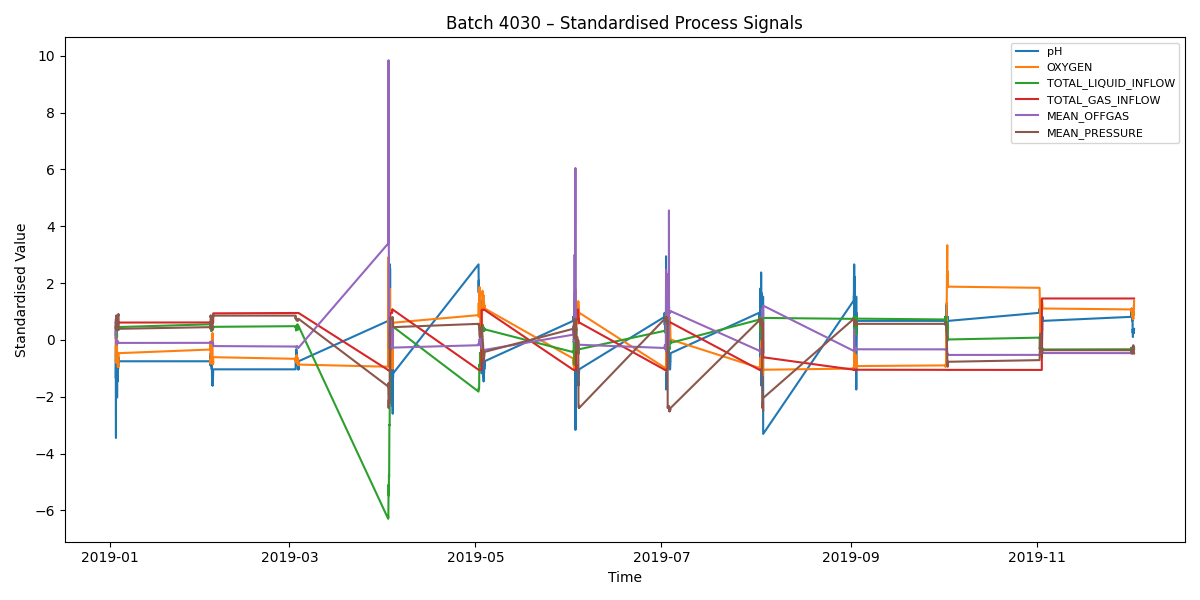

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

def plot_batch_timeseries(ts_df, batch_id):
    """
    Plot all time-series variables for a given batch
    after standardising them (mean=0, std=1).
    """

    # Extract batch
    batch_df = ts_df.loc[batch_id].copy()

    # Drop rows with missing timestamps
    batch_df = batch_df[~batch_df.index.isna()]

    # Standardise features
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(batch_df)

    scaled_df = pd.DataFrame(
        scaled_values,
        index=batch_df.index,
        columns=batch_df.columns
    )

    # Plot
    plt.figure(figsize=(12, 6))

    for col in scaled_df.columns:
        plt.plot(scaled_df.index, scaled_df[col], label=col)

    plt.title(f"Batch {batch_id} – Standardised Process Signals")
    plt.xlabel("Time")
    plt.ylabel("Standardised Value")
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_batch_timeseries(op_df, 4030)


In [ ]:
X, y = build_features_and_target(
    op_df,
    prod_df,
    stats=("mean",)
)

In [ ]:
X

,pH_mean,OXYGEN_mean,TOTAL_LIQUID_INFLOW_mean,TOTAL_GAS_INFLOW_mean,MEAN_OFFGAS_mean,MEAN_PRESSURE_mean
Batch,,,,,,
4030,5.701843,20.290922,25143.546281,7992.039925,2.087056,3.630832
4032,5.752268,22.220957,25225.945362,9441.213757,2.619145,3.534410
4033,5.660681,22.541796,24550.828963,9824.014556,4.402337,3.572248
4034,5.993883,14.902031,24835.980215,9430.686865,4.212649,3.618987
4035,5.640921,17.189599,24603.973947,9409.808277,4.682060,3.595155
4036,5.696832,25.441686,24915.849840,9798.230032,2.920660,3.618753
4037,5.792316,24.395884,23973.361193,8992.184288,5.114926,3.563313
4038,5.800496,26.360232,24890.665139,9076.247232,1.578799,3.610871
4039,5.799887,0.000000,24372.987819,8194.617589,2.702289,3.584045


In [ ]:
X, y = build_features_and_target(
    op_df,
    prod_df,
    stats=("mean", "std", "max", "min"),
    include_last_phase=True,
    include_trends=True,
    include_ranges=True
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score

# Drop missing target rows
mask = y.notna()
X_model = X.loc[mask]
y_model = y.loc[mask]

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42
    ))
])

loo = LeaveOneOut()

scores_mae = cross_val_score(
    pipe,
    X_model,
    y_model,
    cv=loo,
    scoring="neg_mean_absolute_error"
)

mae = -scores_mae.mean()

print("LOOCV MAE:", mae)
print("Relative MAE (%):", 100 * mae / y_model.mean())

LOOCV MAE: 25.72939847076937
Relative MAE (%): 4.173409450221743


In [ ]:
import pandas as pd

def load_operating_data_clean(csv_path: str) -> pd.DataFrame:
    """
    Clean import of 4000 series operating data.
    """

    # Read raw CSV
    df = pd.read_csv(csv_path, low_memory=False)

    # Drop the first two non-data rows (units etc.)
    df = df[df["Batch"].notna()].copy()

    # Convert batch to integer
    df["Batch"] = pd.to_numeric(df["Batch"], errors="coerce").astype(int)

    # Convert timestamp safely
    df["Date and time"] = pd.to_datetime(
        df["Date and time"],
        errors="coerce",
        dayfirst=False  # adjust ONLY if format requires
    )

    # Drop rows where datetime failed
    df = df[df["Date and time"].notna()].copy()

    # Convert all other columns to numeric
    measurement_cols = [
        c for c in df.columns
        if c not in ("Batch", "Date and time")
    ]

    for col in measurement_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Sort properly
    df = df.sort_values(["Batch", "Date and time"])

    # Set multi-index
    df = df.set_index(["Batch", "Date and time"])

    return df


op_df = load_operating_data_clean("4000 series operating data.csv")

# Check number of batches
print(op_df.index.get_level_values("Batch").nunique())

# Check duration of one batch
b = op_df.loc[4030]
print("Start:", b.index.min())
print("End:", b.index.max())
print("Duration (hours):", (b.index.max() - b.index.min()) / pd.Timedelta(hours=1))


22
Start: 2019-01-03 00:01:00
End: 2019-12-02 23:46:00
Duration (hours): 8015.75


/Users/richardfisher/Desktop/Applied/.venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/richardfisher/Desktop/Applied/.venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Users/richardfisher/Desktop/Applied/.venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


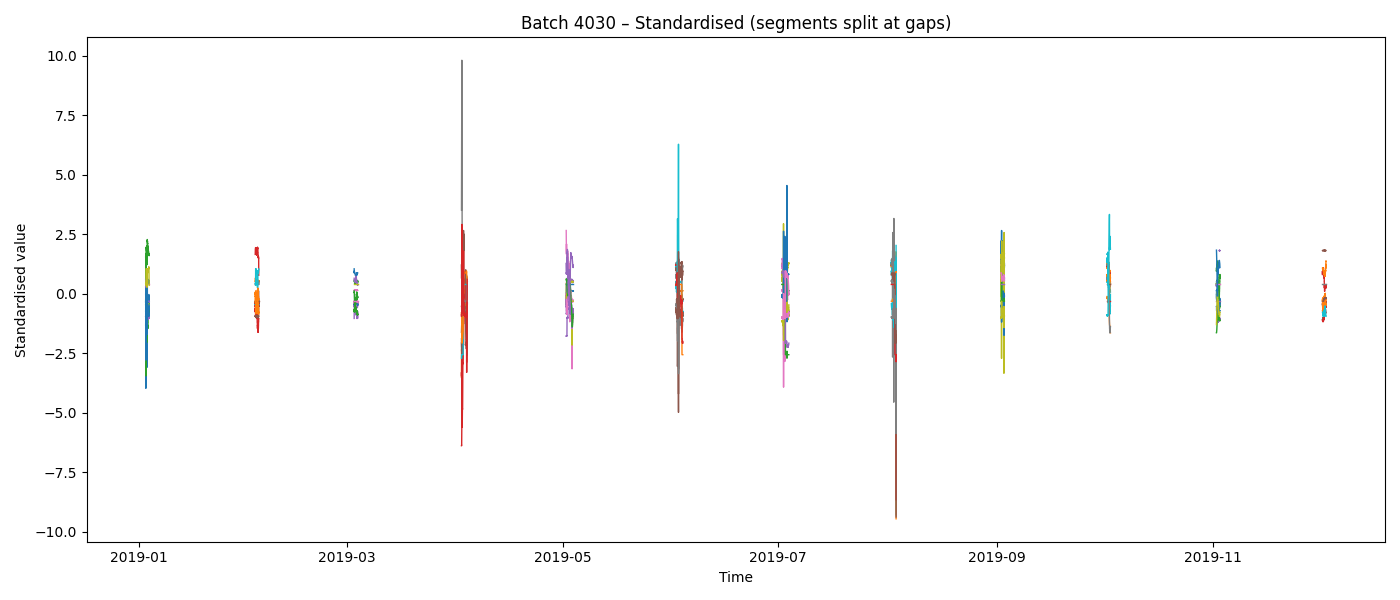

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

def plot_batch_no_gap_connect(df, batch_id, gap_hours=6):
    """
    Plot batch time-series without connecting across large time gaps.
    """

    # Extract batch
    b = df.loc[batch_id].copy()
    b = b.sort_index()

    # Remove NaT if any
    b = b[~b.index.isna()]

    # Detect large gaps
    gaps = b.index.to_series().diff() > pd.Timedelta(hours=gap_hours)
    segment_id = gaps.cumsum()

    # Standardise (for visibility)
    scaler = StandardScaler()
    scaled = pd.DataFrame(
        scaler.fit_transform(b),
        index=b.index,
        columns=b.columns
    )

    # Plot
    plt.figure(figsize=(14, 6))

    for col in scaled.columns:
        for _, segment in scaled[col].groupby(segment_id):
            plt.plot(segment.index, segment.values, linewidth=1)

    plt.title(f"Batch {batch_id} – Standardised (segments split at gaps)")
    plt.xlabel("Time")
    plt.ylabel("Standardised value")
    plt.tight_layout()
    plt.show()
plot_batch_no_gap_connect(op_df, 4030)


In [31]:
import pandas as pd

# -------------------------------------------------
# Load raw CSV
# -------------------------------------------------
df = pd.read_csv("4000 series operating data.csv", low_memory=False)

# Remove rows where Batch is missing
df = df[df["Batch"].notna()].copy()

# Convert types
df["Batch"] = pd.to_numeric(df["Batch"], errors="coerce")

df["Date and time"] = pd.to_datetime(
    df["Date and time"],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

# Drop rows where datetime failed
df = df[df["Date and time"].notna()].copy()

# Convert remaining columns to numeric
for col in df.columns:
    if col not in ["Batch", "Date and time"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# -------------------------------------------------
# Hard-coded Batch → Productivity Rank
# -------------------------------------------------
batch_to_productivity = {
    4041: 1, 4043: 2, 4047: 3, 4040: 4, 4042: 5,
    4046: 6, 4045: 7, 4052: 8, 4034: 9, 4044: 10,
    4032: 11, 4030: 12, 4036: 13, 4033: 14, 4035: 15,
    4048: 16, 4038: 17, 4039: 18, 4037: 19, 4051: 20,
    4050: 21, 4053: 22
}

df["productivity_rank"] = df["Batch"].map(batch_to_productivity)

# Optional productivity tier
def rank_to_tier(rank):
    if rank <= 7:
        return "High"
    elif rank <= 14:
        return "Medium"
    else:
        return "Low"

df["productivity_tier"] = df["productivity_rank"].apply(rank_to_tier)

# -------------------------------------------------
# Aggregate FIRST (before changing index structure)
# -------------------------------------------------
df = aggregate_operating_timeseries(df)

# -------------------------------------------------
# Now add productivity as second index level
# -------------------------------------------------
df = df.reset_index()

df = df.set_index(["productivity_rank", "Batch", "Date and time"])

df = df.sort_index()

df


pH  OXYGEN productivity_tier  \
productivity_rank Batch  Date and time                                         
1                 4041.0 2020-03-18 09:31:00  6.21   10.32              High   
                         2020-03-18 09:46:00  6.12    7.32              High   
                         2020-03-18 10:01:00  5.97    6.87              High   
                         2020-03-18 10:16:00  5.89    7.55              High   
                         2020-03-18 10:31:00  5.91    7.40              High   
...                                            ...     ...               ...   
22                4053.0 2021-05-25 21:15:00  5.83  113.78               Low   
                         2021-05-25 21:20:00  5.72  114.99               Low   
                         2021-05-25 21:25:00  5.62  115.00               Low   
                         2021-05-25 21:30:00  5.53  115.00               Low   
                         2021-05-25 21:35:00  5.45  115.00               Low   

                                              TOTAL_LIQUID_INFLOW  \
productivity_rank Batch  Date and time                              
1                 4041.0 2020-03-18 09:31:00             15690.46   
                         2020-03-18 09:46:00             16297.70   
                         2020-03-18 10:01:00             16284.12   
                         2020-03-18 10:16:00             16278.74   
                         2020-03-18 10:31:00             16285.89   
...                                                           ...   
22                4053.0 2021-05-25 21:15:00             13799.79   
                         2021-05-25 21:20:00             21098.71   
                         2021-05-25 21:25:00             21840.41   
                         2021-05-25 21:30:00             21838.40   
                         2021-05-25 21:35:00             21872.96   

                                              TOTAL_GAS_INFLOW  MEAN_OFFGAS  \
productivity_rank Batch  Date and time                                        
1                 4041.0 2020-03-18 09:31:00           7572.10       28.345   
                         2020-03-18 09:46:00           7600.87       27.755   
                         2020-03-18 10:01:00           7601.10       27.860   
                         2020-03-18 10:16:00           7633.40       28.930   
                         2020-03-18 10:31:00           7637.21       30.065   
...                                                        ...          ...   
22                4053.0 2021-05-25 21:15:00          11741.07        2.590   
                         2021-05-25 21:20:00          11347.51        2.555   
                         2021-05-25 21:25:00          10896.03        2.570   
                         2021-05-25 21:30:00          10562.03        2.555   
                         2021-05-25 21:35:00           9912.25        2.505   

                                              MEAN_PRESSURE  
productivity_rank Batch  Date and time                       
1                 4041.0 2020-03-18 09:31:00          3.300  
                         2020-03-18 09:46:00          3.415  
                         2020-03-18 10:01:00          3.415  
                         2020-03-18 10:16:00          3.420  
                         2020-03-18 10:31:00          3.420  
...                                                     ...  
22                4053.0 2021-05-25 21:15:00          3.555  
                         2021-05-25 21:20:00          3.540  
                         2021-05-25 21:25:00          3.530  
                         2021-05-25 21:30:00          3.520  
                         2021-05-25 21:35:00          3.495  

[83204 rows x 7 columns]

In [32]:
import pandas as pd

def batch_time_diagnostics(df, freq="1H"):

    df = df.copy().reset_index()
    df["Date and time"] = pd.to_datetime(df["Date and time"])

    diagnostics = []

    for batch_id, batch_df in df.groupby("Batch"):

        batch_df = batch_df.sort_values("Date and time")

        start = batch_df["Date and time"].min()
        end = batch_df["Date and time"].max()

        duration = end - start

        duration_hours = duration.total_seconds() / 3600
        duration_days = duration_hours / 24

        # Calendar days spanned
        calendar_days = (end.date() - start.date()).days + 1

        # Expected full date range
        full_range = pd.date_range(start=start, end=end, freq=freq)

        expected_samples = len(full_range)
        actual_samples = batch_df["Date and time"].nunique()

        missing_samples = expected_samples - actual_samples
        percent_missing = (
            100 * missing_samples / expected_samples
            if expected_samples > 0 else 0
        )

        # 🔥 Get productivity rank (same for entire batch)
        productivity_rank = batch_df["productivity_rank"].iloc[0] \
            if "productivity_rank" in batch_df.columns else None

        productivity_tier = batch_df["productivity_tier"].iloc[0] \
            if "productivity_tier" in batch_df.columns else None

        diagnostics.append({
            "Batch": batch_id,
            "productivity_rank": productivity_rank,
            "productivity_tier": productivity_tier,
            "Start": start,
            "End": end,
            "Duration_hours": duration_hours,
            "Duration_days": duration_days,
            "Calendar_days_spanned": calendar_days,
            "Expected_samples": expected_samples,
            "Actual_samples": actual_samples,
            "Missing_samples": missing_samples,
            "Percent_missing": percent_missing
        })

    return (
        pd.DataFrame(diagnostics)
        .set_index("Batch")
        .sort_values("productivity_rank")
    )


# -------------------------------------------------
# Run Diagnostics
# -------------------------------------------------
diag = batch_time_diagnostics(df, freq="1H")

print(diag)


        productivity_rank productivity_tier               Start  \
Batch                                                             
4041.0                  1              High 2020-03-18 09:31:00   
4043.0                  2              High 2020-06-09 19:16:00   
4047.0                  3              High 2020-10-13 23:29:00   
4040.0                  4              High 2020-02-08 11:31:00   
4042.0                  5              High 2020-04-24 00:16:00   
4046.0                  6              High 2020-08-28 01:59:00   
4045.0                  7              High 2020-07-28 20:31:00   
4052.0                  8            Medium 2021-03-10 21:05:00   
4034.0                  9            Medium 2019-07-02 13:01:00   
4044.0                 10            Medium 2020-07-06 23:46:00   
4032.0                 11            Medium 2019-04-01 14:16:00   
4030.0                 12            Medium 2019-02-04 08:46:00   
4036.0                 13            Medium 2019-09-18 12:16:0

C:\Users\richa\AppData\Local\Temp\ipykernel_21008\192882150.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=start, end=end, freq=freq)


In [38]:
import pandas as pd

# -------------------------------------------------
# Load raw CSV
# -------------------------------------------------
df = pd.read_csv("4000 series operating data.csv", low_memory=False)

df = df[df["Batch"].notna()].copy()

df["Batch"] = pd.to_numeric(df["Batch"], errors="coerce")

df["Date and time"] = pd.to_datetime(
    df["Date and time"],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

df = df[df["Date and time"].notna()].copy()

for col in df.columns:
    if col not in ["Batch", "Date and time"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# -------------------------------------------------
# Hard-coded Batch → Productivity Rank
# -------------------------------------------------
batch_to_productivity = {
    4041: 1, 4043: 2, 4047: 3, 4040: 4, 4042: 5,
    4046: 6, 4045: 7, 4052: 8, 4034: 9, 4044: 10,
    4032: 11, 4030: 12, 4036: 13, 4033: 14, 4035: 15,
    4048: 16, 4038: 17, 4039: 18, 4037: 19, 4051: 20,
    4050: 21, 4053: 22
}

df["productivity_rank"] = df["Batch"].map(batch_to_productivity)

def rank_to_tier(rank):
    if rank <= 7:
        return "High"
    elif rank <= 14:
        return "Medium"
    else:
        return "Low"

df["productivity_tier"] = df["productivity_rank"].apply(rank_to_tier)

# -------------------------------------------------
# Aggregate original operating timeseries first
# -------------------------------------------------
df = aggregate_operating_timeseries(df)

# -------------------------------------------------
# Daily Aggregation (KEEP missing days as NaN)
# -------------------------------------------------

df = df.reset_index()

daily_result = []

for (rank, batch), batch_df in df.groupby(["productivity_rank", "Batch"]):

    batch_df = batch_df.sort_values("Date and time")
    batch_df = batch_df.set_index("Date and time")

    # Daily aggregation (mean)
    daily = batch_df.resample("1h").mean(numeric_only=True)

    # Create full daily date range
    full_range = pd.date_range(
        start=daily.index.min(),
        end=daily.index.max(),
        freq="1h"
    )

    # Reindex to keep missing days
    daily = daily.reindex(full_range)

    daily["productivity_rank"] = rank
    daily["Batch"] = batch

    daily_result.append(daily)

# Combine
df_daily = pd.concat(daily_result)

# Set final multi-index
df_daily = df_daily.reset_index()
df_daily = df_daily.rename(columns={"index": "Date"})
df_daily = df_daily.set_index(
    ["productivity_rank", "Batch", "Date"]
).sort_index()

df_daily


pH      OXYGEN  \
productivity_rank Batch  Date                                        
1                 4041.0 2020-03-18 09:00:00  6.165000    8.820000   
                         2020-03-18 10:00:00  5.897500    7.090000   
                         2020-03-18 11:00:00  5.787500    8.435000   
                         2020-03-18 12:00:00  5.795000   38.120000   
                         2020-03-18 13:00:00  5.802500    8.602500   
...                                                ...         ...   
22                4053.0 2021-05-25 17:00:00  5.801667   13.085000   
                         2021-05-25 18:00:00  5.791667   10.825000   
                         2021-05-25 19:00:00  5.803333   12.715833   
                         2021-05-25 20:00:00  5.870833   68.421667   
                         2021-05-25 21:00:00  5.760000  111.818750   

                                              TOTAL_LIQUID_INFLOW  \
productivity_rank Batch  Date                                       
1                 4041.0 2020-03-18 09:00:00         15994.080000   
                         2020-03-18 10:00:00         16277.535000   
                         2020-03-18 11:00:00         18091.965000   
                         2020-03-18 12:00:00         18324.007500   
                         2020-03-18 13:00:00         18315.392500   
...                                                           ...   
22                4053.0 2021-05-25 17:00:00         24041.537500   
                         2021-05-25 18:00:00         23967.733333   
                         2021-05-25 19:00:00         23774.552500   
                         2021-05-25 20:00:00         23788.894167   
                         2021-05-25 21:00:00         21133.936250   

                                              TOTAL_GAS_INFLOW  MEAN_OFFGAS  \
productivity_rank Batch  Date                                                 
1                 4041.0 2020-03-18 09:00:00       7586.485000    28.050000   
                         2020-03-18 10:00:00       7624.742500    29.657500   
                         2020-03-18 11:00:00       8019.370000    33.430000   
                         2020-03-18 12:00:00       8131.182500    31.398750   
                         2020-03-18 13:00:00       8169.685000    18.198750   
...                                                        ...          ...   
22                4053.0 2021-05-25 17:00:00      12223.495833     3.422083   
                         2021-05-25 18:00:00      12232.390833     3.423333   
                         2021-05-25 19:00:00      12229.294167     3.429167   
                         2021-05-25 20:00:00      12187.012500     3.042083   
                         2021-05-25 21:00:00      11354.962500     2.587500   

                                              MEAN_PRESSURE  
productivity_rank Batch  Date                                
1                 4041.0 2020-03-18 09:00:00       3.357500  
                         2020-03-18 10:00:00       3.413750  
                         2020-03-18 11:00:00       3.541250  
                         2020-03-18 12:00:00       3.558750  
                         2020-03-18 13:00:00       3.628750  
...                                                     ...  
22                4053.0 2021-05-25 17:00:00       3.636250  
                         2021-05-25 18:00:00       3.633750  
                         2021-05-25 19:00:00       3.608333  
                         2021-05-25 20:00:00       3.591667  
                         2021-05-25 21:00:00       3.546875  

[14393 rows x 6 columns]

In [39]:
df_daily_reset = df_daily.reset_index()

df_daily_reset.to_csv("daily_operating_data_with_productivity.csv", index=False)

print("Saved to daily_operating_data_with_productivity.csv")

Saved to daily_operating_data_with_productivity.csv


In [26]:
import pandas as pd

import pandas as pd

def batch_time_diagnostics(df, freq="15T"):

    df = df.copy().reset_index()
    df["Date and time"] = pd.to_datetime(df["Date and time"])

    diagnostics = []

    for batch_id, batch_df in df.groupby("Batch"):

        batch_df = batch_df.sort_values("Date and time")

        start = batch_df["Date and time"].min()
        end = batch_df["Date and time"].max()

        duration = end - start

        duration_hours = duration.total_seconds() / 3600
        duration_days = duration_hours / 24

        # Calendar days spanned
        calendar_days = (end.date() - start.date()).days + 1

        # Expected full date range
        full_range = pd.date_range(start=start, end=end, freq=freq)

        expected_samples = len(full_range)
        actual_samples = batch_df["Date and time"].nunique()

        missing_samples = expected_samples - actual_samples
        percent_missing = 100 * missing_samples / expected_samples

        diagnostics.append({
            "Batch": batch_id,
            "Start": start,
            "End": end,
            "Duration_hours": duration_hours,
            "Duration_days": duration_days,
            "Calendar_days_spanned": calendar_days,
            "Expected_samples": expected_samples,
            "Actual_samples": actual_samples,
            "Missing_samples": missing_samples,
            "Percent_missing": percent_missing
        })

    return pd.DataFrame(diagnostics).set_index("Batch")




diag = batch_time_diagnostics(df, freq="1h")
print(diag)

                     Start                 End  Duration_hours  Duration_days  \
Batch                                                                           
4030.0 2019-02-04 08:46:00 2019-03-08 08:16:00      767.500000      31.979167   
4032.0 2019-04-01 14:16:00 2019-05-03 06:31:00      760.250000      31.677083   
4033.0 2019-05-26 17:16:00 2019-06-23 20:01:00      674.750000      28.114583   
4034.0 2019-07-02 13:01:00 2019-08-03 23:46:00      778.750000      32.447917   
4035.0 2019-08-12 17:46:00 2019-09-08 23:46:00      654.000000      27.250000   
4036.0 2019-09-18 12:16:00 2019-10-20 23:46:00      779.500000      32.479167   
4037.0 2019-10-29 04:01:00 2019-11-20 14:31:00      538.500000      22.437500   
4038.0 2019-12-01 01:01:00 2019-12-30 15:31:00      710.500000      29.604167   
4039.0 2020-01-12 11:16:00 2020-01-30 23:46:00      444.500000      18.520833   
4040.0 2020-02-08 11:31:00 2020-03-08 04:01:00      688.500000      28.687500   
4041.0 2020-03-18 09:31:00 2

In [19]:
import pandas as pd

def aggregate_batches_hourly(df, agg_method="mean", fill_method="ffill"):
    """
    Aggregates each batch to 1-hour intervals,
    fills missing hours inside batch date range,
    and converts datetime index to 0,1,2,... per batch.
    """

    # Ensure proper structure
    df = df.copy().reset_index()
    df["Date and time"] = pd.to_datetime(df["Date and time"])

    result = []

    for batch_id, batch_df in df.groupby("Batch"):

        batch_df = batch_df.sort_values("Date and time")
        batch_df = batch_df.set_index("Date and time")

        # 1️⃣ Resample hourly
        batch_hourly = getattr(batch_df.resample("1H"), agg_method)()

        # 2️⃣ Create full hourly range (ensures missing hours exist)
        full_range = pd.date_range(
            start=batch_hourly.index.min(),
            end=batch_hourly.index.max(),
            freq="1H"
        )

        batch_hourly = batch_hourly.reindex(full_range)

        # 3️⃣ Fill missing hours
        if fill_method == "ffill":
            batch_hourly = batch_hourly.ffill()
        elif fill_method == "bfill":
            batch_hourly = batch_hourly.bfill()
        elif fill_method == "zero":
            batch_hourly = batch_hourly.fillna(0)

        # 4️⃣ Replace datetime index with sequential index
        batch_hourly = batch_hourly.reset_index(drop=True)

        # Add batch back
        batch_hourly["Batch"] = batch_id

        result.append(batch_hourly)

    final_df = pd.concat(result)
    final_df = final_df.set_index(["Batch", final_df.groupby("Batch").cumcount()])

    final_df.index.names = ["Batch", "Hour_Index"]

    return final_df


df_hourly = aggregate_batches_hourly(df)


C:\Users\richa\AppData\Local\Temp\ipykernel_21008\1039132003.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  batch_hourly = getattr(batch_df.resample("1H"), agg_method)()
C:\Users\richa\AppData\Local\Temp\ipykernel_21008\1039132003.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(


In [20]:
df_hourly

index        pH      OXYGEN  TOTAL_LIQUID_INFLOW  \
Batch  Hour_Index                                                       
4030.0 0               0.0  5.760000    6.780000         16367.650000   
       1               2.5  5.790000    7.712500         16449.837500   
       2               6.5  5.772500    7.982500         17111.930000   
       3              10.5  5.835000   45.662500         17900.145000   
       4              14.5  5.742500   20.202500         17993.472500   
...                    ...       ...         ...                  ...   
4053.0 673         83153.5  5.801667   13.085000         24041.537500   
       674         83165.5  5.791667   10.825000         23967.733333   
       675         83177.5  5.803333   12.715833         23774.552500   
       676         83189.5  5.870833   68.421667         23788.894167   
       677         83199.5  5.760000  111.818750         21133.936250   

                   TOTAL_GAS_INFLOW  MEAN_OFFGAS  MEAN_PRESSURE     timestamp  
Batch  Hour_Index                                                              
4030.0 0                  55.140000     9.405000       3.470000  1.549270e+09  
       1                  55.197500    13.666250       3.473750  1.549272e+09  
       2                  62.695000    20.258750       3.455000  1.549276e+09  
       3                  41.145000    22.562500       3.430000  1.549279e+09  
       4                  68.392500    15.806250       3.417500  1.549283e+09  
...                             ...          ...            ...           ...  
4053.0 673             12223.495833     3.422083       3.636250  1.621964e+09  
       674             12232.390833     3.423333       3.633750  1.621967e+09  
       675             12229.294167     3.429167       3.608333  1.621971e+09  
       676             12187.012500     3.042083       3.591667  1.621974e+09  
       677             11354.962500     2.587500       3.546875  1.621977e+09  

[14393 rows x 8 columns]

In [21]:
import dearpygui.dearpygui as dpg

# -----------------------
# Prepare Data
# -----------------------

# Make sure index is accessible
df_plot = df_hourly.reset_index()  # brings Batch and Hour_Index back as columns

# -----------------------
# DearPyGui Setup
# -----------------------

dpg.create_context()

with dpg.window(label="Hourly Total Liquid Inflow (All Batches)", width=1000, height=600):

    with dpg.plot(label="Hourly Inflow by Batch", height=-1, width=-1):

        dpg.add_plot_legend()

        x_axis = dpg.add_plot_axis(dpg.mvXAxis, label="Hour Index")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="TOTAL_LIQUID_INFLOW")

        # -----------------------
        # Loop Through Batches
        # -----------------------

        for batch_id, batch_data in df_plot.groupby("Batch"):

            x_data = batch_data["Hour_Index"].tolist()
            y_data = batch_data["TOTAL_LIQUID_INFLOW"].tolist()

            dpg.add_line_series(
                x_data,
                y_data,
                label=f"Batch {int(batch_id)}",
                parent=y_axis
            )

# -----------------------
# Launch
# -----------------------

dpg.create_viewport(title="Hourly Batch Plot", width=1200, height=700)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()


In [16]:
import pandas as pd
import dearpygui.dearpygui as dpg

# -----------------------
# Prepare Data
# -----------------------

# Example: assuming df already exists
batch_id = 4030.0

batch_df = (
    df
    .xs(batch_id, level="Batch")
    [["TOTAL_LIQUID_INFLOW"]]
    .reset_index()
)

# Convert datetime to pandas datetime (important)
batch_df["Date and time"] = pd.to_datetime(batch_df["Date and time"])

# Convert datetime to numeric timestamps (DearPyGui requires float)
batch_df["timestamp"] = batch_df["Date and time"].astype("int64") / 1e9

x_data = batch_df["timestamp"].tolist()
y_data = batch_df["TOTAL_LIQUID_INFLOW"].tolist()

# -----------------------
# DearPyGui App
# -----------------------

dpg.create_context()

with dpg.window(label="Batch 4030 - Total Liquid Inflow", width=900, height=500):

    with dpg.plot(label="Liquid Inflow Plot", height=-1, width=-1):

        dpg.add_plot_legend()

        # X axis (time)
        x_axis = dpg.add_plot_axis(dpg.mvXAxis, label="Time")

        # Y axis
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="TOTAL_LIQUID_INFLOW")

        # Add line series
        dpg.add_line_series(
            x_data,
            y_data,
            label="Liquid Inflow",
            parent=y_axis
        )

dpg.create_viewport(title="Batch Plot", width=1000, height=600)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()


In [17]:
import pandas as pd
import dearpygui.dearpygui as dpg

# -----------------------
# Prepare Data
# -----------------------

# Ensure datetime format
df = df.copy()
df = df.reset_index()
df["Date and time"] = pd.to_datetime(df["Date and time"])

# Convert datetime to timestamp float
df["timestamp"] = df["Date and time"].astype("int64") / 1e9

# -----------------------
# DearPyGui Setup
# -----------------------

dpg.create_context()

with dpg.window(label="All Batches - Total Liquid Inflow", width=1000, height=600):

    with dpg.plot(label="Liquid Inflow by Batch", height=-1, width=-1):

        dpg.add_plot_legend()

        x_axis = dpg.add_plot_axis(dpg.mvXAxis, label="Time")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="TOTAL_LIQUID_INFLOW")

        # -----------------------
        # Loop Through Batches
        # -----------------------

        for batch_id, batch_data in df.groupby("Batch"):

            x_data = batch_data["timestamp"].tolist()
            y_data = batch_data["TOTAL_LIQUID_INFLOW"].tolist()

            dpg.add_line_series(
                x_data,
                y_data,
                label=f"Batch {int(batch_id)}",
                parent=y_axis
            )

# -----------------------
# Launch
# -----------------------

dpg.create_viewport(title="All Batches Plot", width=1200, height=700)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()


In [11]:
# --- Extract batch ---
b = df.loc[4030.0].sort_index()

# --- Denoise (rolling median) ---
b_denoised = b.rolling(window=5, center=True).median()

# --- Downsample to hourly using mean ---
b = b_denoised.resample("1h").mean()

b


,pH,OXYGEN,TOTAL_LIQUID_INFLOW,TOTAL_GAS_INFLOW,MEAN_OFFGAS,MEAN_PRESSURE
Date and time,,,,,,
2019-02-04 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2019-02-04 09:00:00,5.786667,7.446667,16448.556667,55.733333,14.486667,3.471667
2019-02-04 10:00:00,5.772500,7.982500,17116.292500,62.340000,20.258750,3.455000
2019-02-04 11:00:00,5.810000,33.400000,17897.270000,48.240000,22.360000,3.432500
2019-02-04 12:00:00,5.755000,20.220000,17991.572500,65.385000,15.806250,3.420000
...,...,...,...,...,...,...
2019-03-08 04:00:00,5.695000,3.752500,24863.790000,7594.610000,4.432500,3.415000
2019-03-08 05:00:00,5.685000,1.870000,24861.185000,7590.902500,4.448750,3.420000
2019-03-08 06:00:00,5.680000,0.632500,24856.180000,7592.185000,4.445000,3.420000


In [12]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

scaled = pd.DataFrame(
    scaler.fit_transform(b),
    index=b.index,
    columns=b.columns
)

scaled.plot(figsize=(14,6))

plt.title("Batch 4030 – Standardised Variables")
plt.xlabel("Time")
plt.ylabel("Standardised value")
plt.tight_layout()
plt.show()


ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

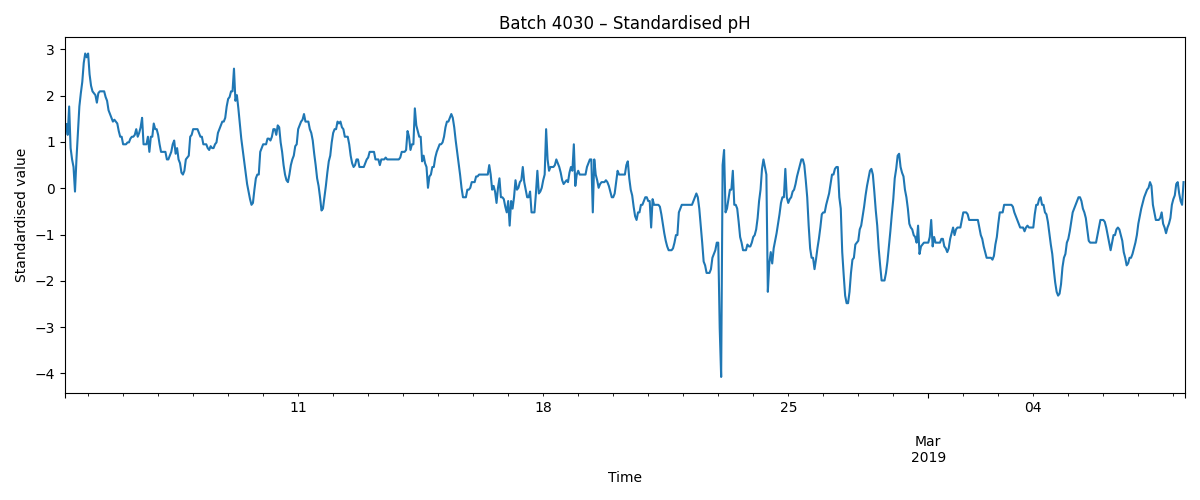

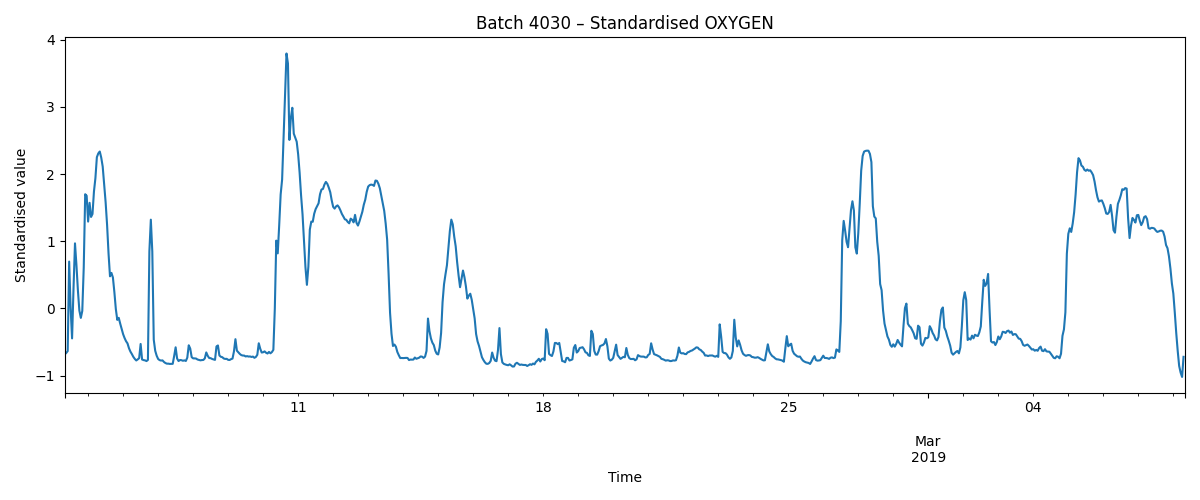

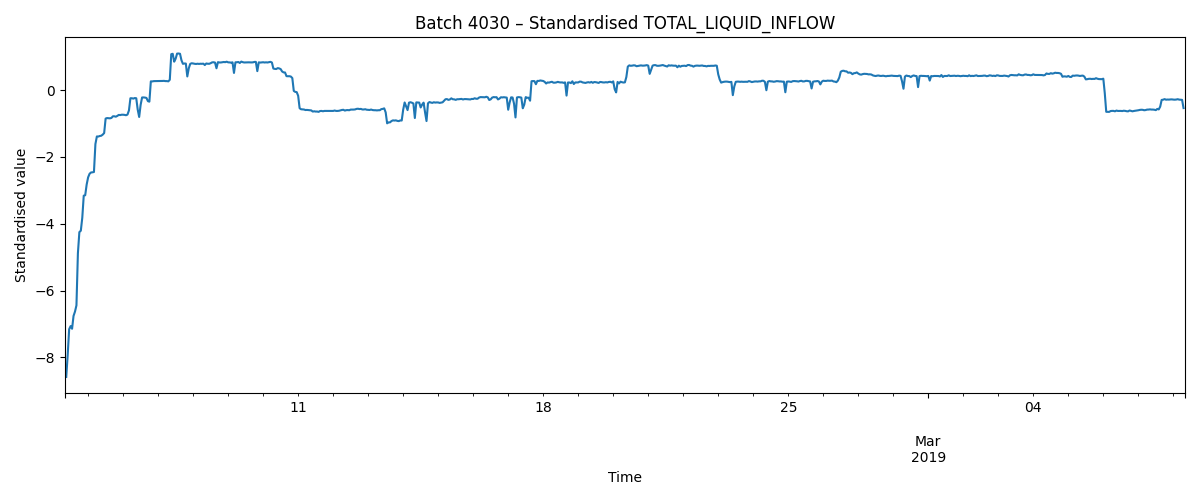

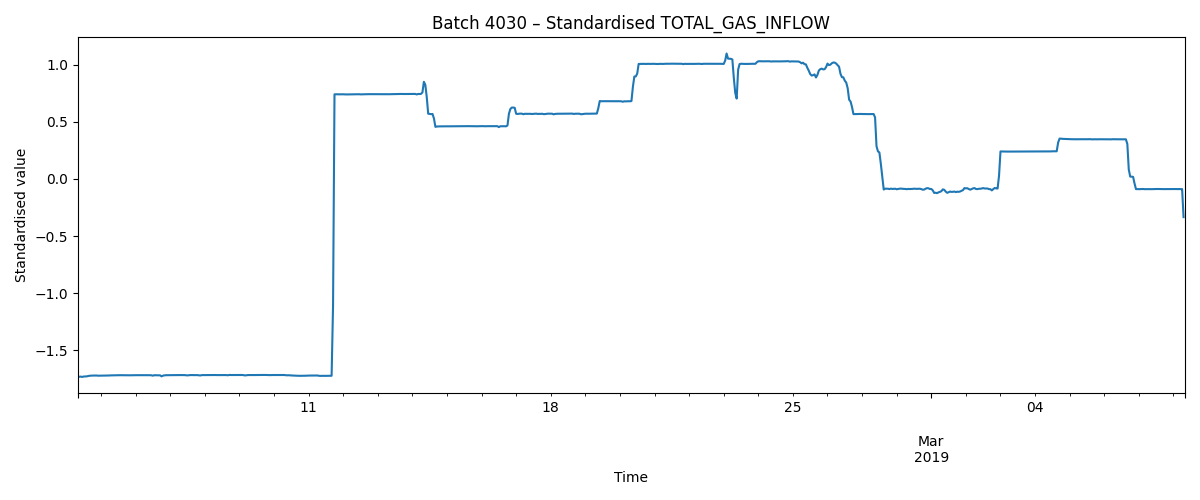

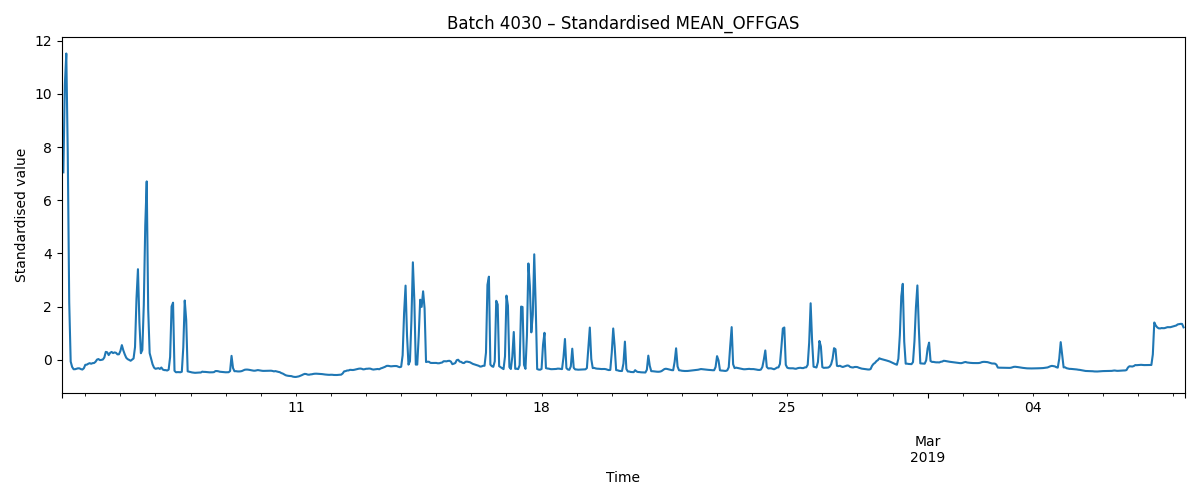

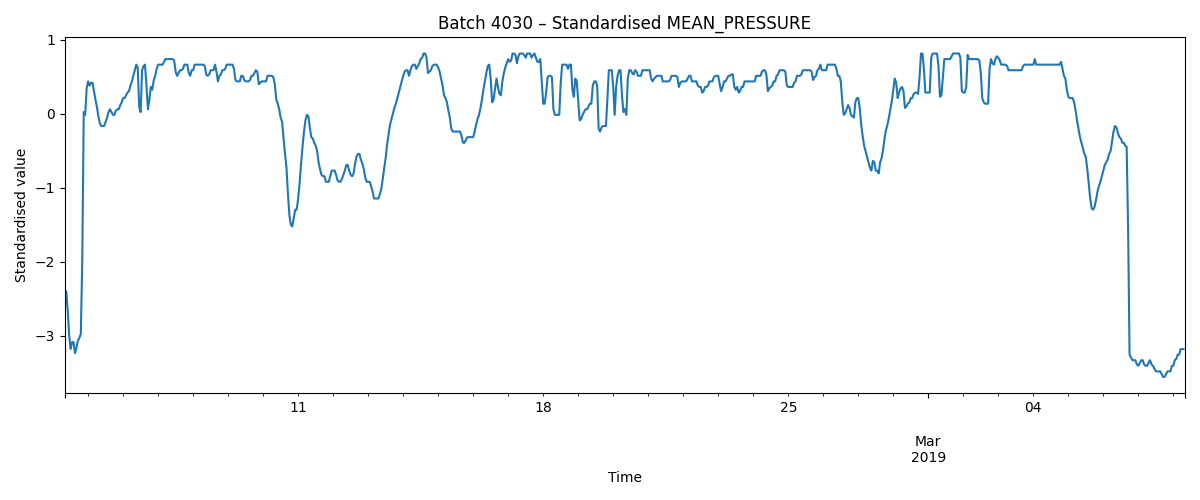

In [102]:
import matplotlib.pyplot as plt

for col in scaled.columns:
    plt.figure(figsize=(12, 5))
    
    scaled[col].plot()
    
    plt.title(f"Batch 4030 – Standardised {col}")
    plt.xlabel("Time")
    plt.ylabel("Standardised value")
    plt.tight_layout()
    plt.show()


In [93]:
b_denoised = b.copy()

b_denoised["OXYGEN"] = (
    b["OXYGEN"]
    .rolling(window=5, center=True)
    .median()
)

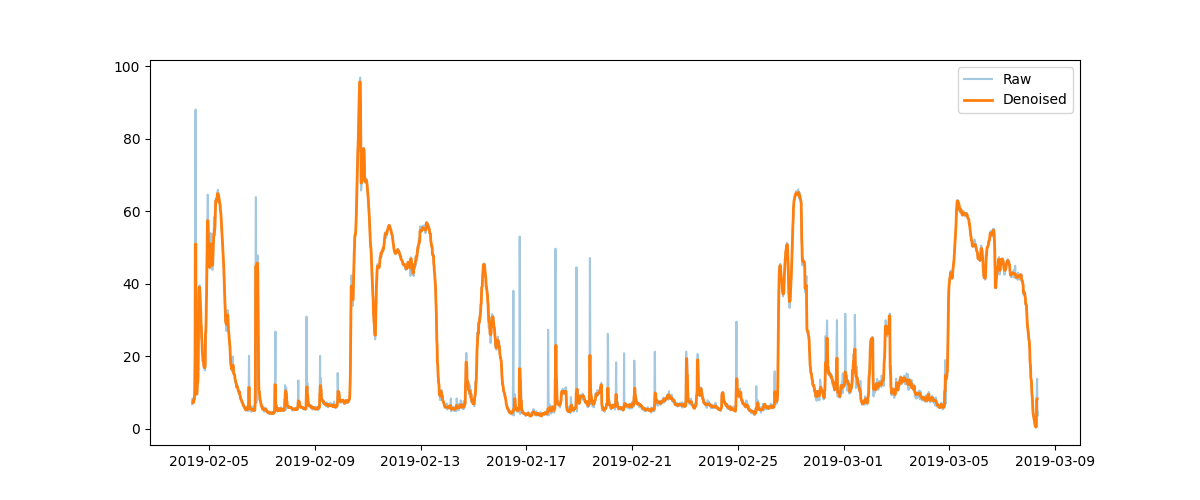

In [94]:
plt.figure(figsize=(12,5))
plt.plot(b["OXYGEN"], alpha=0.4, label="Raw")
plt.plot(b_denoised["OXYGEN"], linewidth=2, label="Denoised")
plt.legend()
plt.show()